In [1]:
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision.transforms import v2

import sys
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import numpy as np

import json
from tqdm import tqdm
from PIL import Image

plt.style.use('dark_background')

# LR_Sheduler

In [2]:
class MyModel(nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input, 128),
            nn.ReLU(),
            nn.Linear(128, output)
        )

    def forward(self, x):
        return self.model(x)

In [3]:
model = MyModel(784, 10)

loss_model = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.1)

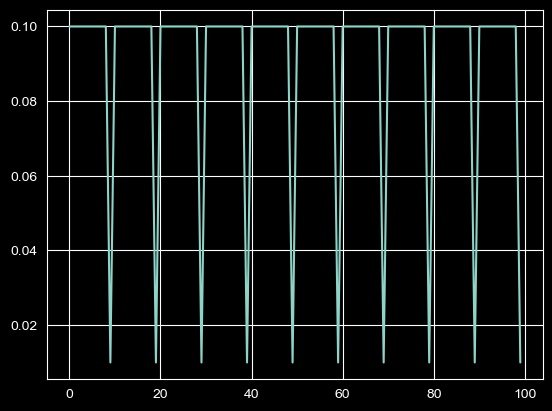

In [4]:
# LambdaLR
lr_lambda = lambda step: 0.1 if step % 10 == 0 else 1
lr_scheduler = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=lr_lambda)

list_ = []
for epoch in range(100):

    # Train
    for _ in range(1):
        # forward pass
        # backward pass
        opt.step()


    # Validation
        # forward pass

    lr_scheduler.step()
    lr = lr_scheduler.get_last_lr()
    list_.append(lr)

plt.plot(list_)
plt.show()

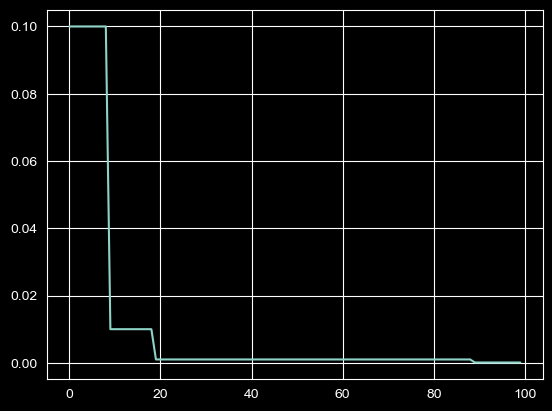

In [5]:
# MultiStepLR
model = MyModel(784, 10)

loss_model = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr = 0.1)

lr_scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[10, 20, 90], gamma=0.1)

list_ = []
for epoch in range(100):

    # Train
    for _ in range(1):
        # forward pass
        # backward pass
        opt.step()


    # Validation
        # forward pass

    lr_scheduler.step()

    lr = lr_scheduler.get_last_lr()
    list_.append(lr)

plt.plot(list_)
plt.show()

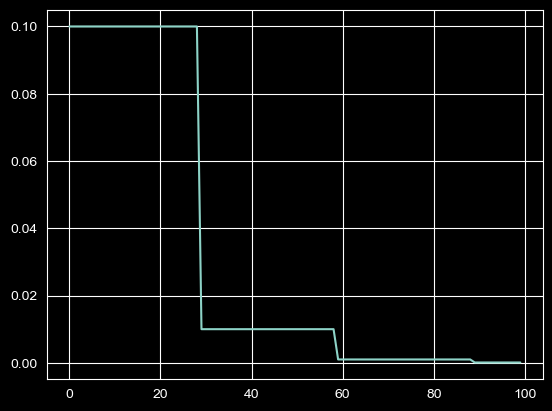

In [6]:
# StepLR
model = MyModel(784, 10)

loss_model = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr = 0.1)

lr_scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=30, gamma=0.1)

list_ = []
for epoch in range(100):

    # Train
    for _ in range(1):
        # forward pass
        # backward pass
        opt.step()

    # Validation
        # forward pass

    lr_scheduler.step()

    lr = lr_scheduler.get_last_lr()
    list_.append(lr)

plt.plot(list_)
plt.show()

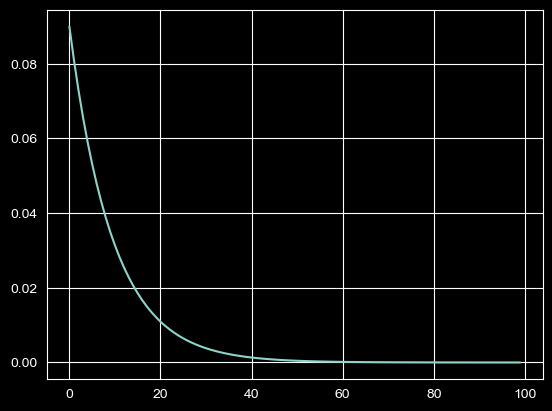

In [7]:
# ExponentialLR
model = MyModel(784, 10)

loss_model = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr = 0.1)

lr_scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9)

list_ = []
for epoch in range(100):

    # Train
    for _ in range(1):
        # forward pass
        # backward pass
        opt.step()

    # Validation
        # forward pass

    if epoch % 5 == 0:
        lr_scheduler.step()

    lr = lr_scheduler.get_last_lr()
    list_.append(lr)

plt.plot(list_)
plt.show()

In [14]:
# ReduceLROnPlateau
model = MyModel(784, 10)

loss_model = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr = 0.1)

lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt,     # оптимизатор.
                                                          mode='min',    # 'max' или 'min' - следим, чтобы отслеживаемый параметр увеличивался...
                                                          factor=0.1,    # коэффициент, на который будет умножен lr.
                                                          patience=5,   # кол-во эпох без улучшения отслеживаемого параметра.
                                                          threshold=0.0001,  # порог, на который должен измениться отслеживаемый параметр.
                                                          threshold_mode='rel', # 'rel' или 'abs'. Если 'rel', то отслеживаемый параметр должен измениться на threshold процентов, иначе на просто на threshold
                                                          cooldown=0,    # кол-во периодов ожидания после уменьшения lr.
                                                          min_lr=0,      # минимальное значение скорости обучения.
                                                          eps=1e-8       # минимальное изменение между новым и старым lr.
                                                          )

In [15]:
loss = torch.full([5, 10], 0.1)
loss = loss * torch.tensor([1/i for i in range(1, 6)]).reshape([5, 1])
loss = loss.reshape([50])

In [16]:
list_ = []
for epoch in range(50):

    # Train
    for _ in range(1):
        # forward pass
        # backward pass
        opt.step()

    # Validation
        # forward pass

    idx = epoch
    lr_scheduler.step(loss[idx])

    lr = lr_scheduler._last_lr[0]
    list_.append(lr)

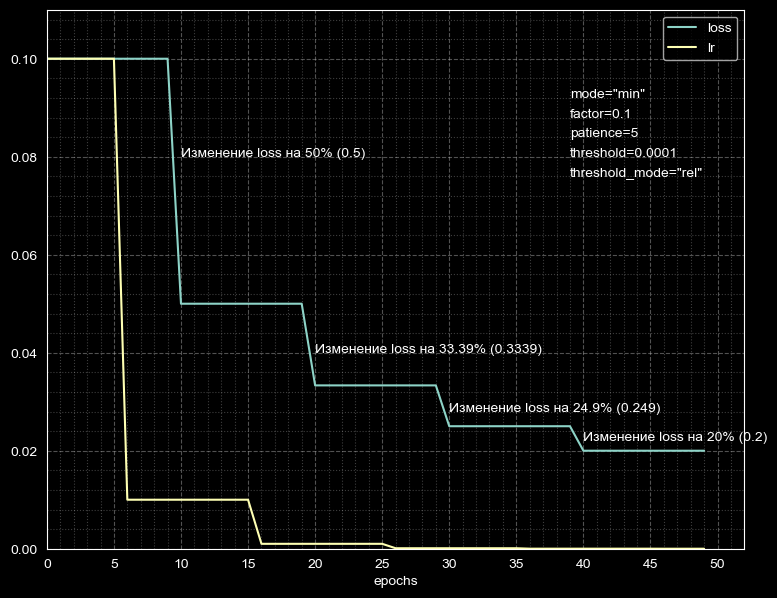

In [17]:
fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(loss)
ax.plot(list_)

ax.set_xlim(0, 52)
ax.set_ylim(0, 0.11)

ax.xaxis.set_major_locator(MultipleLocator(5))

ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))

ax.grid(which='major', color='#CCCCCC', linestyle='--', alpha=0.4)
ax.grid(which='minor', color='#CCCCCC', linestyle=':', alpha=0.3)

ax.legend(["loss", "lr"])
ax.set_xlabel('epochs')

if lr_scheduler.threshold_mode == "abs":
    ax.text(10, 0.08, 'Изменение loss на 0.05')
    ax.text(20, 0.04, 'Изменение loss на 0.0167')
    ax.text(30, 0.028, 'Изменение loss на 0.008')
    ax.text(40, 0.022, 'Изменение loss на 0.005')
else:
    ax.text(10, 0.08, 'Изменение loss на 50% (0.5)')
    ax.text(20, 0.04, 'Изменение loss на 33.39% (0.3339)')
    ax.text(30, 0.028, 'Изменение loss на 24.9% (0.249)')
    ax.text(40, 0.022, 'Изменение loss на 20% (0.2)')

ax.text(39, 0.092, f'mode="{lr_scheduler.mode}"')
ax.text(39, 0.088, f'factor={lr_scheduler.factor}')
ax.text(39, 0.084, f'patience={lr_scheduler.patience}')
ax.text(39, 0.080, f'threshold={lr_scheduler.threshold}')
ax.text(39, 0.076, f'threshold_mode="{lr_scheduler.threshold_mode}"')

plt.show()

# Применение ReduceLROnPlateau на задачи регрессии

## Создание датасета

In [18]:
# Определяем устройство для работы
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [19]:
class DataSetReg(Dataset):
    def __init__(self, path, transform=None):
        self.path = path
        self.transform = transform

        self.list_name_file = os.listdir(path)
        if 'coords.json' in self.list_name_file:
            self.list_name_file.remove('coords.json')

        self.len_dataset = len(self.list_name_file)

        with open(os.path.join(self.path, 'coords.json'), 'r') as fl:
            self.dict_coords = json.load(fl)

    def __len__(self):
        return self.len_dataset

    def __getitem__(self, index):
        name_file = self.list_name_file[index]
        path_img = os.path.join(self.path, name_file)

        img = np.array(Image.open(path_img))
        coord = np.array(self.dict_coords[name_file])

        if self.transform is not None:
            img = self.transform(img)

        return img, coord

In [20]:
# Преобразования для изображения
transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=(0.5,), std=(0.5,))
    ]
)

In [21]:
dataset = DataSetReg('/drive/MyDrive/Colab_Notebooks/content/dataset/', transform=transform) if 'google.colab' in sys.modules \
    else DataSetReg('/Users/SashaCurry/PyCharmMiscProject/content/dataset/', transform=transform)

In [22]:
train_set, val_set, test_set = random_split(dataset, [0.7, 0.1, 0.2])

In [23]:
# Создание загрузчиков
train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
val_loader = DataLoader(val_set, batch_size=16, shuffle=False)
test_loader = DataLoader(test_set, batch_size=16, shuffle=False)

## Создание модели

In [24]:
class MyModel(nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.layer_1 = nn.Linear(input, 128)
        self.layer_2 = nn.Linear(128, output)
        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.layer_1(x)
        x = self.activation(x)
        out = self.layer_2(x)
        return out


model = MyModel(64*64, 2).to(device)

In [25]:
# Проверяем правильность модели
input = torch.rand([16, 64*64], dtype=torch.float32).to(device)

out = model(input)
print(out.shape)

torch.Size([16, 2])


In [27]:
loss_model = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=0.001)
lr_sheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt,
                                                         mode='min',
                                                         factor=0.1,
                                                         patience=5)

## Тренировка модели

In [28]:
EPOCHS = 60
train_loss = []
train_acc = []
val_loss = []
val_acc = []
lr_list = []

In [2]:
# Цикл обучения
for epoch in range(EPOCHS):
    # Тренировка модели
    running_train_loss = []
    mean_train_loss = 0
    train_loop = tqdm(train_loader, leave=False) # создание progress bar
    true_answer = 0

    model.train()
    for x, targets in train_loop:
        # Данные
        # (batch_size, 1, 64, 64) -> (batch_size, 64*64)
        x = x.reshape(-1, 64*64).to(device)
        targets = targets.to(torch.float32).to(device)

        # Прямой проход + расчет ошибки модели
        pred = model(x)
        loss = loss_model(pred, targets)

        # Обратный проход
        opt.zero_grad()
        loss.backward()
        # Шаг оптимизации
        opt.step()

        running_train_loss.append(loss.item())
        mean_train_loss = sum(running_train_loss) / len(running_train_loss)

        true_answer += (torch.round(pred) == targets).all(dim=1).sum().item()

        train_loop.set_description(f'Epoch [{epoch+1}/{EPOCHS}], train_loss={mean_train_loss:.4f}')

    # Расчет значения метрики
    running_train_acc = true_answer / len(train_set)

    # Сохранение значения функции потерь и метрики
    train_loss.append(mean_train_loss)
    train_acc.append(running_train_acc)

    # Проверка модели (валидация)
    model.eval()
    with torch.no_grad():
        running_val_loss = []
        true_answer = 0
        for x, targets in val_loader:
            # Данные
            # (batch_size, 1, 64, 64) -> (batch_size, 64*64)
            x = x.reshape(-1, 64*64).to(device)
            targets = targets.to(torch.float32).to(device)

            # Прямой проход + расчет ошибки модели
            pred = model(x)
            loss = loss_model(pred, targets)

            running_val_loss.append(loss.item())
            mean_val_loss = sum(running_val_loss) / len(running_val_loss)

            true_answer += (torch.round(pred) == targets).all(dim=1).sum().item()

        # Расчет значения метрики
        running_val_acc = true_answer / len(val_set)

        # Сохранение значения функции потерь и метрики
        val_loss.append(mean_val_loss)
        val_acc.append(running_val_acc)

        lr_sheduler.step(mean_val_loss)
        lr = opt.param_groups[0]['lr']
        lr_list.append(lr)

        print(f'Epoch [{epoch+1}/{EPOCHS}]: train_loss={mean_train_loss:.4f}, train_acc={running_train_acc:.4f}, val_loss={mean_val_loss:.4f}, val_acc={running_val_acc:.4f}, lr={lr:.4f}')

NameError: name 'EPOCHS' is not defined

In [1]:
plt.plot(lr_list)
plt.show()

NameError: name 'plt' is not defined

In [ ]:
plt.plot(train_loss)
plt.plot(val_loss)
plt.legend(['loss_train', 'loss_val'])
plt.show()

In [ ]:
plt.plot(train_acc)
plt.plot(val_acc)
plt.legend(['acc_train', 'acc_val'])
plt.show()